# Alignment Tutorial for SM and ST Data via SpatialMETA

The raw ST and SM data exhibit different morphologies and resolutions. After alignment with spatialMETA, the ST and SM data were successfully aligned, allowing the SM data, which lack H&E images, to be projected onto H&E images derived from the ST data

In [1]:
import sys
sys.path.append("/public/home/off_liukunpeng/project/14_SpatialT2M/comparision_software/SpatialMETA")

In [2]:
import spatialmeta as smt
from spatialmeta.model import AlignmentModule
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import copy
import matplotlib.pyplot as plt

/public/home/off_liukunpeng/.local/lib/python3.9/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Read and preprocess data

The ST and SM data are read from h5ad files using the `smt.read_h5ad_st()` and `smt.read_h5ad_sm()` functions, respectively. The ST data is then normalized and log-transformed using the `normalize_non_inplace()` function. The top spatial variable genes/metabolites are identified using the `smt.pp.spatial_variable()` function. And the test data can be available from `load_adata()`

### read data

Read raw ST and SM data in h5ad format. 

In [3]:
# If data is available
st_path = "/public/home/off_liukunpeng/project/8_spatial_multi_omics/1_SMA/end_data/package/data/sma/V11T16-085_B1/V11T16-085_B1_RNA/st.h5ad"
sm_path = "/public/home/off_liukunpeng/project/8_spatial_multi_omics/1_SMA/end_data/package/data/sma/V11T16-085_B1/V11T16-085_B1_MSI/ms.h5ad"
adata_st = smt.read_h5ad_st(st_path)
adata_sm = smt.read_h5ad_sm(sm_path)
adata_st.var_names_make_unique()
adata_sm.obsm["spatial"]=np.array([list(adata_sm.obs["array_col"]*-1+100),list(adata_sm.obs["array_row"])]).T

In [4]:

org_coor=[[61.000000,12.000000],
[38.000000,68.000000],
[40.000000,50.000000],
[64.000000,50.000000],
[21.000000,72.000000]]



he_coor=[
[494.000000,220.000000],
[1058.000000,1585.000000],
[1023.000000,1144.000000],
[444.000000,1143.000000],
[1480.000000,1691.000000],
]
org_coor=np.array(org_coor)
org_coor[:,0]=org_coor[:,0]*-1+100
he_coor=np.array(he_coor)


In [ ]:
sample_is

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

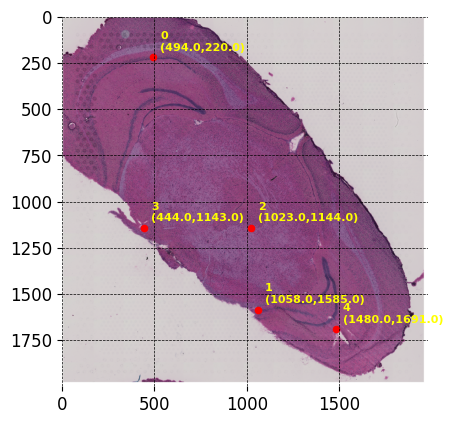

In [5]:
coords = he_coor
st_adata=adata_st
plt.imshow(st_adata.uns['spatial']['V11T16-085_B1']['images']['hires'])
# 添加黑色网格线
plt.grid(True, color='black', linestyle='--', linewidth=0.5, alpha=1)

# 隐藏坐标轴刻度（保留网格线）
# ax.set_xticks([])  # 隐藏 x 轴刻度
# ax.set_yticks([])  # 隐藏 y 轴刻度
# 或者完全隐藏边框
ax = plt.gca()  # 获取当前 axes
for spine in ax.spines.values():
    spine.set_visible(False)
# plt.axis('off')  # 隐藏横纵坐标轴
plt.scatter(coords[:,0], coords[:,1], c='red', s=20)
for i, (x, y) in enumerate(coords):
    plt.annotate(f'{i}\n({x:.1f},{y:.1f})', 
                xy=(x, y), xytext=(5, 5), 
                textcoords='offset points',
                color='yellow', fontsize=8,fontweight='bold')
# plt.savefig('output.png')

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

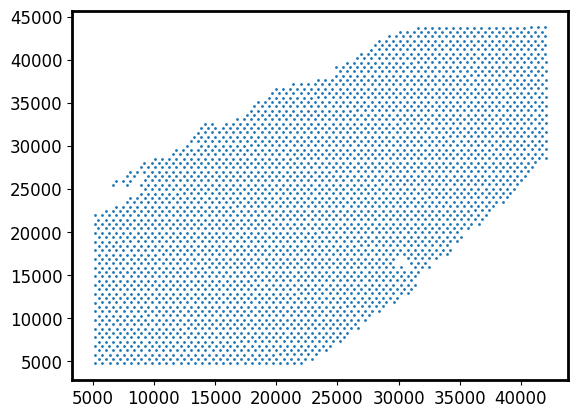

In [6]:
plt.scatter(adata_st.obsm["spatial"][:,0],adata_st.obsm["spatial"][:,1],s=1)

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

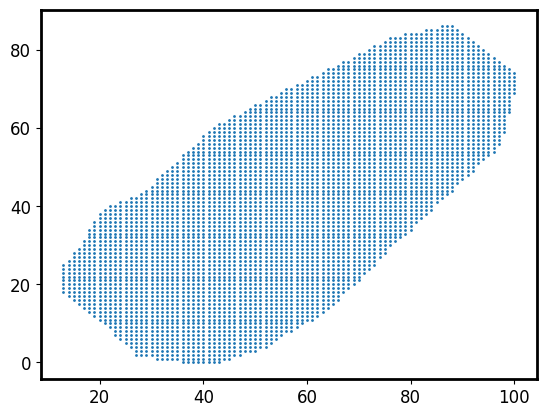

In [7]:
plt.scatter(adata_sm.obsm["spatial"][:,0],adata_sm.obsm["spatial"][:,1],s=1)
# plt.scatter(adata_st.obsm["spatial"][:,0],adata_st.obsm["spatial"][:,1],s=1)

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

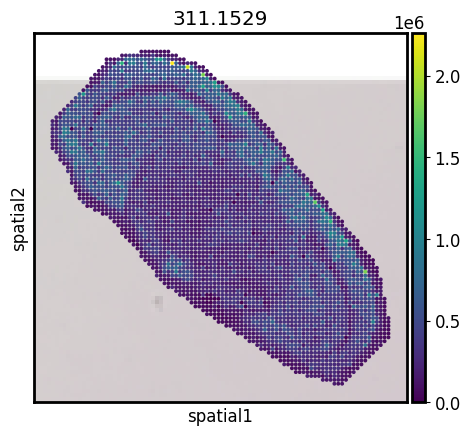

In [8]:
sc.pl.spatial(adata_sm,color=adata_sm.var_names[250])


findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

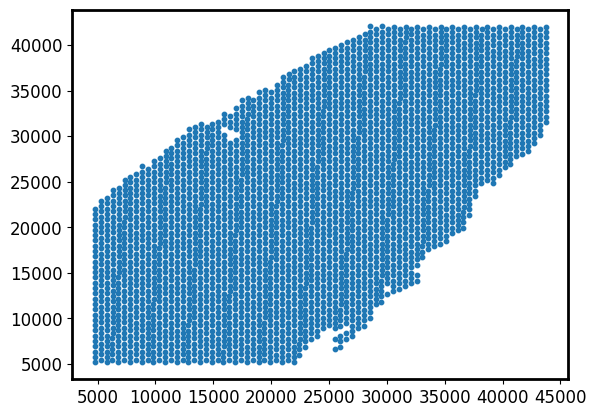

In [9]:
plt.scatter(adata_st.obsm["spatial"][:,1],adata_st.obsm["spatial"][:,0],s=10)


findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

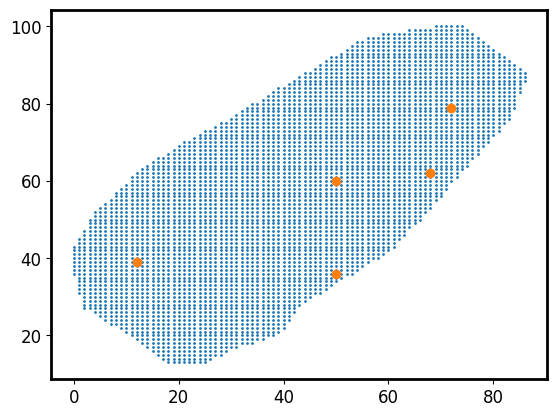

In [10]:

plt.scatter(adata_sm.obsm["spatial"][:,1],adata_sm.obsm["spatial"][:,0],s=1)
plt.scatter(org_coor[:,1],org_coor[:,0])

In [11]:
obs_index=[]
for j in org_coor:
    n=0
    for i in adata_sm.obsm['spatial']:
        if (i[0]==int(j[0])) and (i[1]==int(j[1])):
            print(n)
            obs_index.append(n)
        n+=1

364
3613
2598
2622
3778


findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

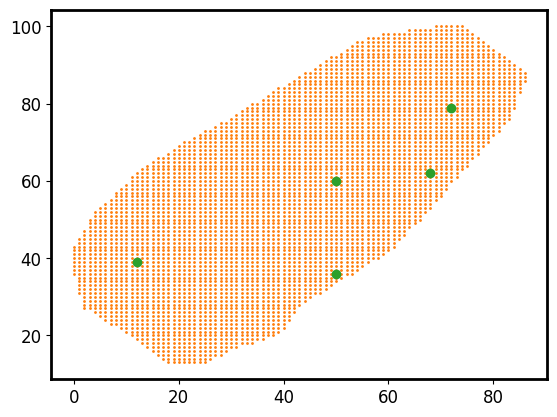

In [12]:
plt.scatter(adata_sm.obsm["spatial"][obs_index,1],adata_sm.obsm["spatial"][obs_index,0],s=1)
plt.scatter(adata_sm.obsm["spatial"][:,1],adata_sm.obsm["spatial"][:,0],s=1)
plt.scatter(org_coor[:,1],org_coor[:,0])

In [13]:
#Test data can be obtained from SpatialMETA
# adata_st = smt.data.load_adata(
#     sample_name="Y7_T_raw",
#     modality="ST"
# )
# adata_sm = smt.data.load_adata(
#     sample_name="Y7_T_raw",
#     modality="SM"
# )

### preprocess ST data

Normalize the ST data through the scanpy.pp.normalize_total() and scanpy.pp.log1p().

In [14]:
def normalize_non_inplace(adata):
    adata.layers['normalized'] = copy.deepcopy(adata.X)
    sc.pp.normalize_total(adata, layer='normalized')
    sc.pp.log1p(adata, layer='normalized')
normalize_non_inplace(adata_st)

Calculate the top spatial variable genes using the moranI method, which provid by the Squidpy

In [15]:
smt.pp.spatial_variable(
    adata_st,
    n_top_variable=2000,
    add_key= "highly_variable_moranI",
    layer='normalized'
)

In [16]:
adata_st = adata_st[:,adata_st.var['highly_variable_moranI']]

scale x to 0-100 and keep aspect ratio

In [17]:
xmin,xmax = adata_st.obsm['spatial'][:,0].min(), adata_st.obsm['spatial'][:,0].max()
adata_st.obsm['spatial_normalized'] = (adata_st.obsm['spatial'] - xmin) / (xmax - xmin) * 100

### preprocess SM data

Normalize the SM data through the scanpy.pp.normalize_total

In [18]:
sc.pp.normalize_total(adata_sm, target_sum=1e3)

Calculate the top spatial variable metabolites using the moranI method, which provid by the Squidpy

In [19]:
smt.pp.spatial_variable(
    adata_sm,
    n_top_variable=500,
    add_key= "highly_variable_moranI",
)

In [20]:
adata_sm = adata_sm[:,adata_sm.var['highly_variable_moranI']]

In [21]:
xmin,xmax = adata_sm.obsm['spatial'][:,0].min(), adata_sm.obsm['spatial'][:,0].max()

To ensure alignment between the SM and ST data, the SM data locations are manually adjusted. This involves rotating the SM image to match the orientation of the ST data. The `smt.pl.plot_spot_sm_st()` function is used to visualize the alignment before and after adjustment.

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

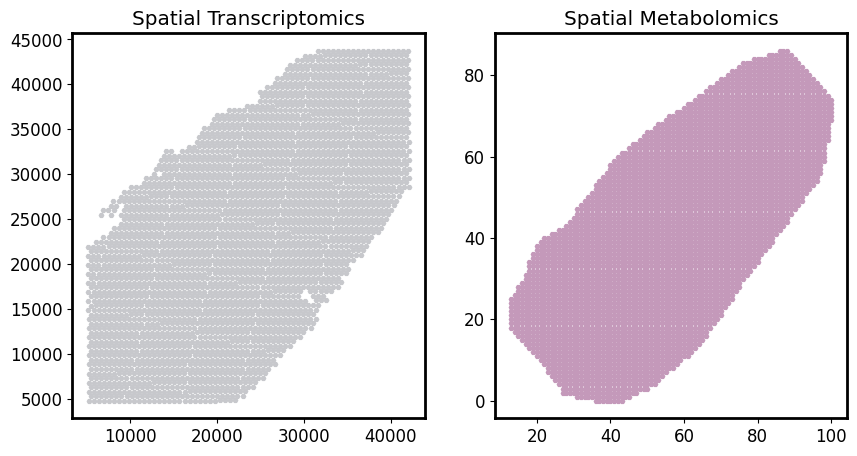

In [22]:
smt.pl.plot_spot_sm_st(adata_SM = adata_sm,
                       adata_ST = adata_st,
                       marker = 'H',
                       SM_spatial_key = "spatial")

In [23]:
smt.pp.spot_transform_by_manual(
    adata = adata_sm,
    rotation =0,
    spatial_key_SM = "spatial",
    new_spatial_key_SM = "spatial"
)

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

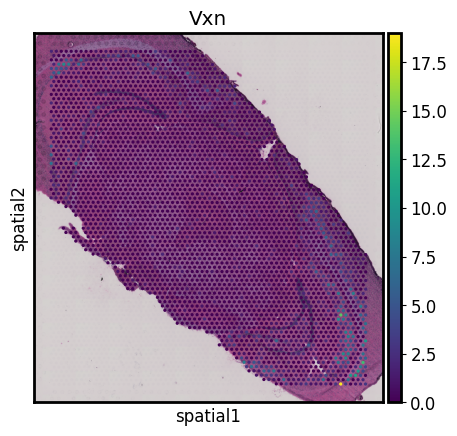

In [24]:
sc.pl.spatial(adata_st,color=adata_st.var_names[0])

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

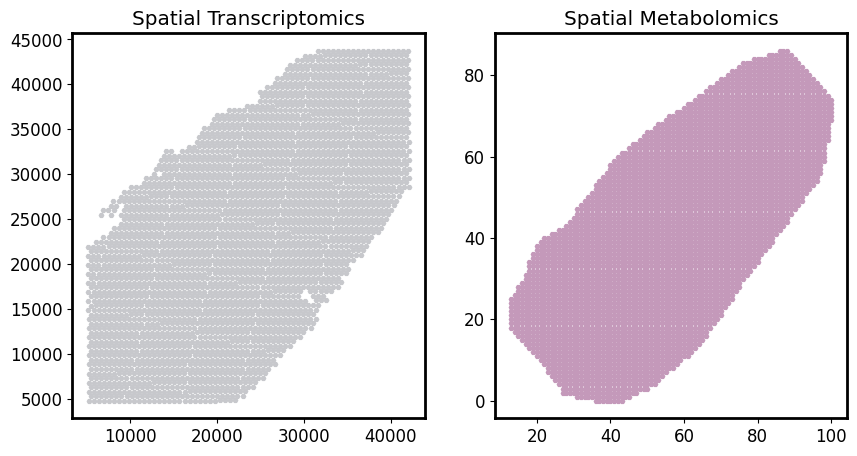

In [25]:
smt.pl.plot_spot_sm_st(adata_SM = adata_sm,
                       adata_ST = adata_st,
                       marker = 'H',
                       SM_spatial_key = "spatial")

scale x to 0-100 and keep aspect ratio

In [26]:
adata_sm.obsm['spatial_normalized'] = (adata_sm.obsm['spatial'] - xmin) / (xmax - xmin) * 100

## Alignment Model

An AlignmentModule model is created using the `AlignmentModule()` class. The model is trained using the `fit_vae()` function, which minimizes the reconstruction loss between the aligned SM and ST data.

### Create and fit the model

Create an AlignmentModule model obejct use AlignmentModule().

In [27]:
model = AlignmentModule(
    adata_st=adata_st,
    adata_sm=adata_sm,
    n_latent=10,
    device='cuda:0'
)

Now train model.

In [28]:
loss_dict = model.fit_vae(max_epoch=128)

Epoch: 100%|██████████| 128/128 [01:05<00:00,  1.96it/s, reconst_sm=-3.93e+00, reconst_st=1.35e+01, kldiv=5.50e-01]


Plot the rasterized feature map.

Latent Embedding: |          | 33/? [00:00<00:00, 151.29it/s]
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not fo

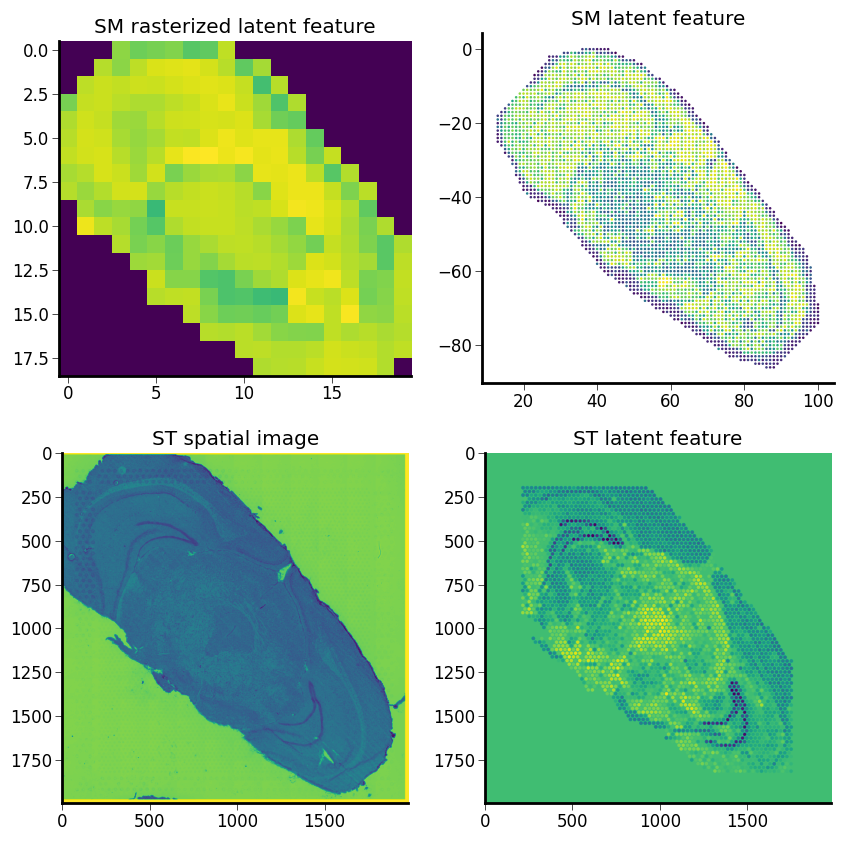

In [29]:
data = model.get_rasterized_feature_map()

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

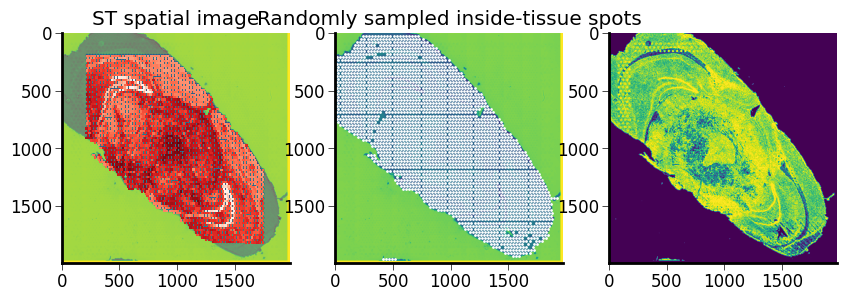

In [30]:
random_sample_inside_image_spot = model.random_sample_inside_image_spot(data)

The alignment results are evaluated using the `fit_alignment()` function, which calculates the alignment loss for different alignment configurations. The best alignment configuration is selected based on the lowest alignment loss. The aligned SM data is then saved to a new h5ad file using the `write_h5ad()` function.

In [31]:
result = model.fit_alignment(
    data,
    debug_path = './tmp/figures/point_alignment',
    # align_st_feature = False
)

LLDDMM: 100%|████████████████████| 500/500 [00:13<00:00, 38.17it/s, EM=0, ER=0, EP=0.74, angle=-0.014]   


### Save and visualize the model results

In [32]:
best = list(result.keys())[np.argmin(np.array([result[x]['loss'][-1] for x in result.keys()]))]

In [33]:
adata_sm.obsm['spatial_transformed'] = result[best]['pointsIt']

Visualization of the alignment results

In [34]:
smt.pp.calculate_qc_metrics_sm(adata_sm)

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

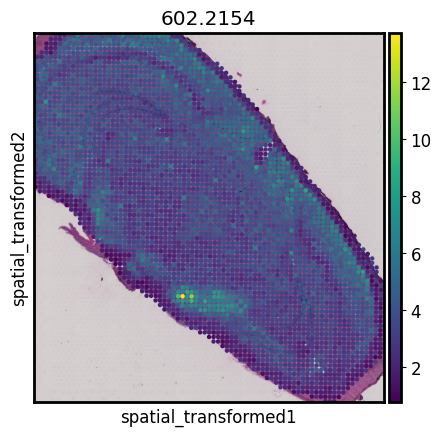

In [35]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots()
sc.pl.spatial(adata_st, 
              show=False,
              ax=ax)
sc.pl.embedding(adata_sm,
                basis="spatial_transformed",
                ax=ax,
                s=40,
                color=adata_sm.var_names[300])

In [36]:
adata_sm.obsm['spatial_transformed'][obs_index,:]
# obs_index

array([[ 540.0552 ,  275.5061 ],
       [1027.6838 , 1503.2292 ],
       [ 989.0789 , 1110.1709 ],
       [ 463.34818, 1103.1973 ],
       [1398.9194 , 1595.386  ]], dtype=float32)

In [37]:
he_coor

array([[ 494.,  220.],
       [1058., 1585.],
       [1023., 1144.],
       [ 444., 1143.],
       [1480., 1691.]])

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

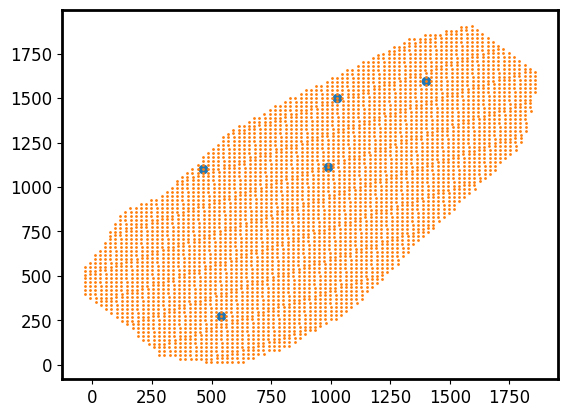

In [38]:
plt.scatter(adata_sm.obsm['spatial_transformed'][obs_index,0],adata_sm.obsm['spatial_transformed'][obs_index,1])
plt.scatter(adata_sm.obsm['spatial_transformed'][:,0],adata_sm.obsm['spatial_transformed'][:,1],s=1)
# plt.scatter(he_coor[:,0],he_coor[:,1])

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

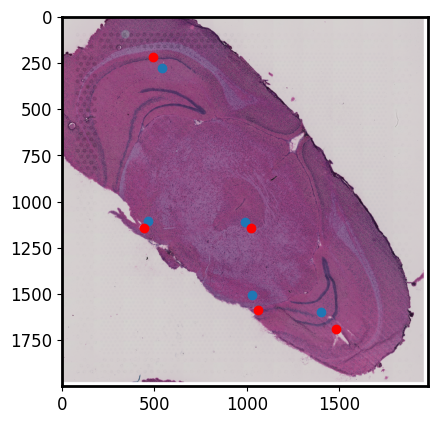

In [39]:
plt.imshow(st_adata.uns['spatial'][sample_is]['images']['hires'])
plt.scatter(adata_sm.obsm['spatial_transformed'][obs_index,0],adata_sm.obsm['spatial_transformed'][obs_index,1],c="blue")
plt.scatter(he_coor[:,0],he_coor[:,1],c="red")
plt.gca().invert_yaxis()

plt.scatter(he_coor[:,0], he_coor[:,1], c='red', s=20)

for i, (x, y) in enumerate(adata_sm.obsm['spatial_transformed'][obs_index,:]):
    plt.annotate(f'{i}\n({x:.1f},{y:.1f})', 
                xy=(x, y), xytext=(5, 5), 
                textcoords='offset points',
                color='blue', fontsize=8,fontweight='bold')
    
for i, (x, y) in enumerate(he_coor):
    plt.annotate(f'{i}\n({x:.1f},{y:.1f})', 
                xy=(x, y), xytext=(5, 5), 
                textcoords='offset points',
                color='red', fontsize=8,fontweight='bold')

In [40]:
adata_sm.uns["landmark_index"]=obs_index
adata_sm.write_h5ad("085B1_spatialmeta.h5ad")

In [41]:
adata_sm

AnnData object with n_obs × n_vars = 4130 × 500
    obs: 'array_row', 'array_col', 'total_intensity', 'mean_intensity'
    var: 'highly_variable_moranI'
    uns: 'spatial', 'spatial_neighbors', 'moranI', 'landmark_index'
    obsm: 'spatial', 'spatial_normalized', 'spatial_transformed'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [42]:
from sklearn.metrics import mean_squared_error,mean_absolute_error


In [43]:
pred=adata_sm.obsm['spatial_transformed'][obs_index,:]

In [44]:
rmse_per_point=[]
mae_per_point=[]
for i in range(5):
    index_i=mean_squared_error(he_coor[i],pred[i])
    rmse_i=np.sqrt(index_i)
    rmse_per_point.append(rmse_i)
    
    mae_i=mean_absolute_error(he_coor[i],pred[i])
    mae_per_point.append(mae_i)



findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

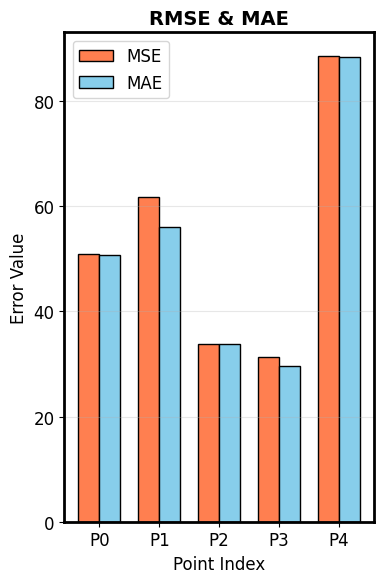

In [45]:
import matplotlib.pyplot as plt
import numpy as np

rmse_values = rmse_per_point
mae_values = mae_per_point
point_labels = ['P0', 'P1', 'P2', 'P3', 'P4']

x = np.arange(len(point_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(4, 6))

# 绘制两组柱子
bars1 = ax.bar(x - width/2, rmse_per_point, width, label='MSE', color='coral', edgecolor='black')
bars2 = ax.bar(x + width/2, mae_values, width, label='MAE', color='skyblue', edgecolor='black')

# 设置标签
ax.set_xlabel('Point Index', fontsize=12)
ax.set_ylabel('Error Value', fontsize=12)
ax.set_title('RMSE & MAE', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(point_labels)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# # 在柱子上显示数值
# for bar in bars1:
#     height = bar.get_height()
#     ax.annotate(f'{height:.2f}',
#                 xy=(bar.get_x() + bar.get_width() / 2, height),
#                 xytext=(0, 3), textcoords="offset points",
#                 ha='center', va='bottom', fontsize=9)

# for bar in bars2:
#     height = bar.get_height()
#     ax.annotate(f'{height:.2f}',
#                 xy=(bar.get_x() + bar.get_width() / 2, height),
#                 xytext=(0, 3), textcoords="offset points",
#                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
# plt.show()
plt.savefig("085B1_RMSE_MAE.png",dpi=300)